In [2]:
import pandas as pd 


In [3]:
df = pd.read_csv(r"data/mass_data.csv", encoding="latin-1")
df.head()

,message,is_spam
0,"Go until jurong point, crazy.. Available only ...",False
1,Ok lar... Joking wif u oni...,False
2,Free entry in 2 a wkly comp to win FA Cup fina...,True
3,U dun say so early hor... U c already then say...,False
4,"Nah I don't think he goes to usf, he lives aro...",False


In [4]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5870 entries, 0 to 5869
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  5870 non-null   object
 1   is_spam  5870 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 51.7+ KB


,message,is_spam
count,5870,5870
unique,5467,2
top,"Sorry, I'll call later",False
freq,30,4974


In [5]:
df.count()

message    5870
is_spam    5870
dtype: int64

In [6]:
df["is_spam"].value_counts()

is_spam
False    4974
True      896
Name: count, dtype: int64

<Axes: xlabel='is_spam'>

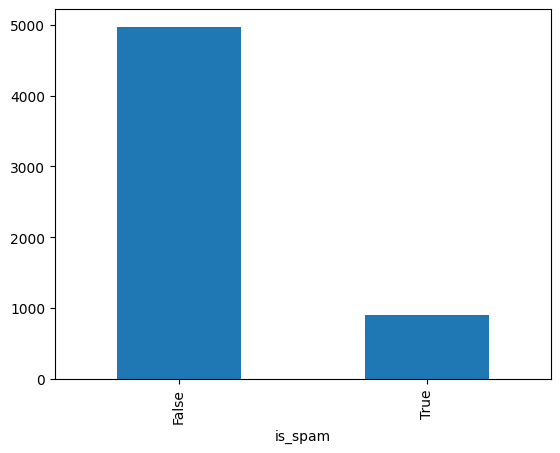

In [7]:
df["is_spam"].value_counts().plot(kind="bar")

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

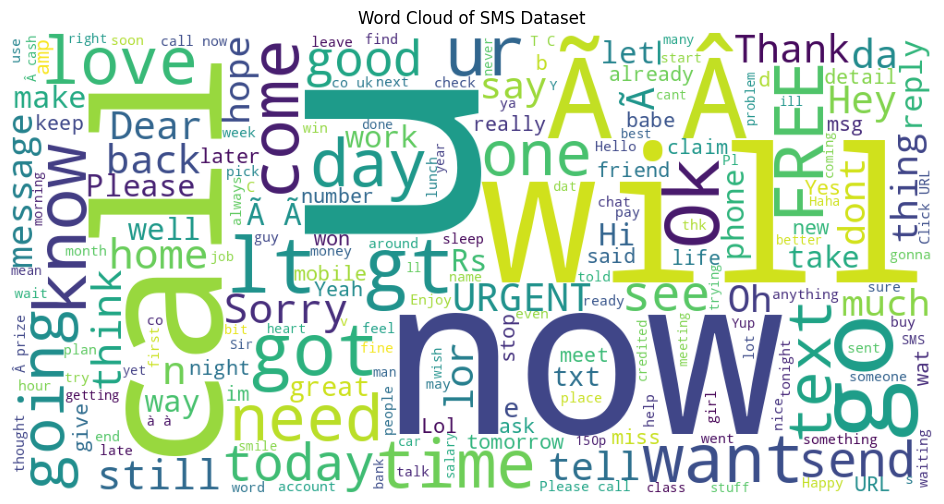

In [9]:
text = " ".join(df["message"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of SMS Dataset")
plt.show()

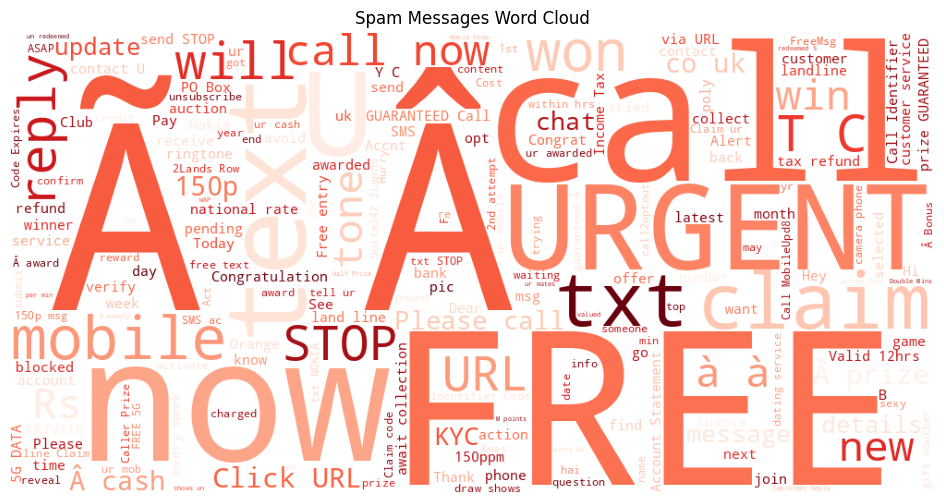

In [10]:
spam_text = " ".join(df[df["is_spam"] == True]["message"].astype(str))

wordcloud_spam = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Reds"
).generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_spam)
plt.axis("off")
plt.title("Spam Messages Word Cloud")
plt.show()

In [11]:
df["msg_length"] = df["message"].str.len()

df.groupby("is_spam")["msg_length"].describe()

,count,mean,std,min,25%,50%,75%,max
is_spam,,,,,,,,
False,4974.0,72.805991,58.309194,2.0,34.0,54.0,97.0,910.0
True,896.0,142.760045,32.690378,13.0,132.0,151.0,160.0,328.0


<Axes: title={'center': 'msg_length'}, xlabel='is_spam'>

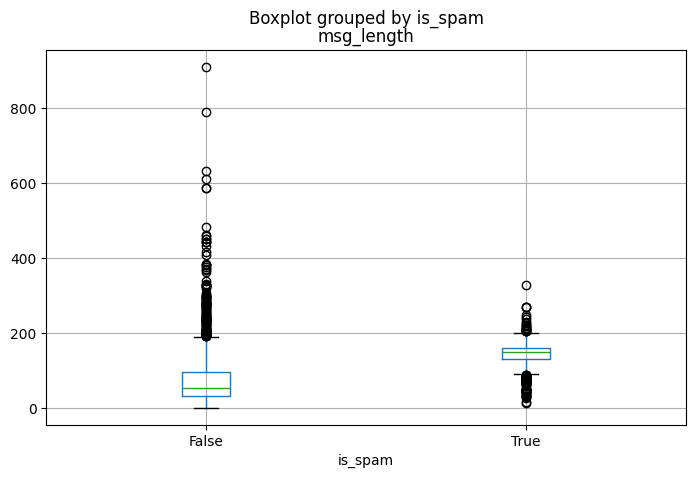

In [12]:
df.boxplot(column="msg_length", by="is_spam", figsize=(8,5))

# BASE LINE MODEL 

In [13]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

ImportError: cannot import name 'Sequence' from 'collections' (c:\Users\adars\.conda\envs\college\lib\collections\__init__.py)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

In [ ]:
df = df[["message","is_spam"]]
df.dropna(inplace=True)

df.head()

In [ ]:
df["is_spam"] = df["is_spam"].astype(int)

Text Cleaning + Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):

    words = nltk.word_tokenize(text.lower())

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(words)

df["clean_text"] = df["message"].apply(preprocess)

df.head()

TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df["clean_text"])

y = df["is_spam"]

Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression Model (OLS style baseline)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

(Very Useful) Top Spam Words

In [ ]:
feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

top_spam = np.argsort(coefficients)[-20:]

for i in reversed(top_spam):
    print(feature_names[i], coefficients[i])